# Pole to Victory: 20 Years of F1 Competitiveness

**Alison Carvajal Paulino**

**Student ID: 70095663**

Formula 1 is arguably the most data-intensive sport in the world. There is a common belief that "the race is won on Saturday" during qualifying. The main goal of this project is to use real historical data to prove whether starting grid position dictates the final outcome, or if there is room for a comeback.

To test this, the project compares the 2005 and 2025 seasons to evaluate whether modern innovations have significantly altered race outcomes or if Saturday remains just as decisive as two decades ago.

### Regulatory Context: 2005 vs. 2025
Contrasting the regulatory landscapes of 2005 and 2025 is essential.

**2005 season**
- Tire changes were banned, so one set of tires had to last all race.
- Qualifying was a single lap driven with race fuel in the car.
- V10 engines and front-wing aerodynamics created strong dirty air.
- Overtaking on track was very hard, making Saturday's grid position key to winning.

**2025 Season**
- Ground-effect cars and DRS reduce dirty air to make overtaking easier.
- Mandatory pit stops with different tire compounds force strategy choices.
- Low-fuel qualifying (Q1-Q2-Q3) tests pure top speed for one lap, not how fast the car is during the race.
- V6 turbo-hybrid engines and race strategy allow drivers to win even if they do not start on pole.


After this brief introduction, let's start with our code:

In [115]:
import re
import bs4
import requests
import pandas as pd
import time
import matplotlib.pyplot as plt

### Driver Position Extraction

The `grid_position` function fetches a session page from *StatsF1*, parses the main results table (`ctl00_CPH_Main_GV_Stats`) with *BeautifulSoup*, and returns an ordered list of driver names.

In [116]:
# Function to extract driver positions
def grid_position(url, session): 
    response = session.get(url)
    data = bs4.BeautifulSoup(response.text, 'html.parser')  #De aquí extraeremos los datos

    # Find the qualy/race results table
    table = data.find(id="ctl00_CPH_Main_GV_Stats")

    # Find drivers data
    body = table.find('tbody')
    rows = body.find_all("tr")

    # List of names ordered by position (to compare later)
    names = [] 
    for row in rows:
        found = row.find('a')
        if found:
            names.append(found.text.strip())

    return names


### Data Scraping and Dataset Construction

This block loops through the races common to both the 2005 and 2025 seasons to extract qualifying and race results from *StatsF1*. 
It calculates whether the pole-sitter won the race, finds the starting grid position of the eventual winner, and stores the results in a structured Pandas DataFrame.

In [117]:
# List of years and race endpoints to easily construct URLs
years = [2005, 2025]
races = ["bahrein", "belgique", "canada", "espagne", "monaco", "italie", "australie", "chine", "japon", "grande-bretagne", "hongrie", "etats-unis"]

# To prevent HTTP request blocking
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'es-ES,es;q=0.9',
}

session = requests.Session()
session.headers.update(headers)


# Loop through each season and race
results = []

for year in years:
    for race in races:
        url = f"https://www.statsf1.com/es/{year}/{race}/qualification.aspx"

        qualy = grid_position(url, session)

        url = f"https://www.statsf1.com/es/{year}/{race}/classement.aspx"

        race_day = grid_position(url, session)

        time.sleep(2)

        # Dictionary with all the data from each race
        pole = qualy[0]
        winner = race_day[0]
        pole_winner = (pole == winner)

        race_data = {
            'year': year,
            'race': race,
            'pole': pole,
            'winner': winner,
            'pole_wins': pole_winner,
            'start_position_of_winner': (qualy.index(winner) + 1)
        }

        results.append(race_data)


# Create a DataFrame to work with a single tabular dataset
df = pd.DataFrame(results)
df.sort_values('year')


,year,race,pole,winner,pole_wins,start_position_of_winner
0,2005,bahrein,Fernando ALONSO,Fernando ALONSO,True,1
10,2005,hongrie,Michael SCHUMACHER,Kimi RAIKKONEN,False,4
9,2005,grande-bretagne,Fernando ALONSO,Juan-Pablo MONTOYA,False,4
8,2005,japon,Ralf SCHUMACHER,Kimi RAIKKONEN,False,17
7,2005,chine,Fernando ALONSO,Fernando ALONSO,True,1
6,2005,australie,Giancarlo FISICHELLA,Giancarlo FISICHELLA,True,1
11,2005,etats-unis,Jarno TRULLI,Michael SCHUMACHER,False,5
4,2005,monaco,Kimi RAIKKONEN,Kimi RAIKKONEN,True,1
3,2005,espagne,Kimi RAIKKONEN,Kimi RAIKKONEN,True,1
2,2005,canada,Jenson BUTTON,Kimi RAIKKONEN,False,7


### Statistical Aggregation by Grid Position

This section splits the dataset by year and computes the percentage of race wins categorized into three grid tiers:
 Pole position (P1), front-runners (P2–P3), and midfield or back-grid comebacks (P4+).

In [118]:
# Separate the data by year
mean_2005 = df[df.year == 2005]
mean_2025 = df[df.year == 2025]


# Win percentage from Pole Position (P1)
mean_pole_2005 = (mean_2005['start_position_of_winner'] == 1).mean() * 100
mean_pole_2025 = (mean_2025['start_position_of_winner'] == 1).mean() * 100


# Win percentage from 2nd or 3rd place (P2–P3)
mean_no_pole_2005 = (mean_2005['start_position_of_winner'].isin([2, 3])).mean() * 100
mean_no_pole_2025 =  (mean_2025['start_position_of_winner'].isin([2, 3])).mean() * 100


# Win percentage from 4th place or lower (P4+)
p4_2005 = (mean_2005['start_position_of_winner'] >= 4).mean() * 100
p4_2025 = (mean_2025['start_position_of_winner'] >= 4).mean() * 100

### Comparative Visualization (Pie Charts)

This block generates side-by-side pie charts comparing the distribution of race winners across grid position tiers (P1, P2–P3, and P4+) between the 2005 and 2025 seasons.

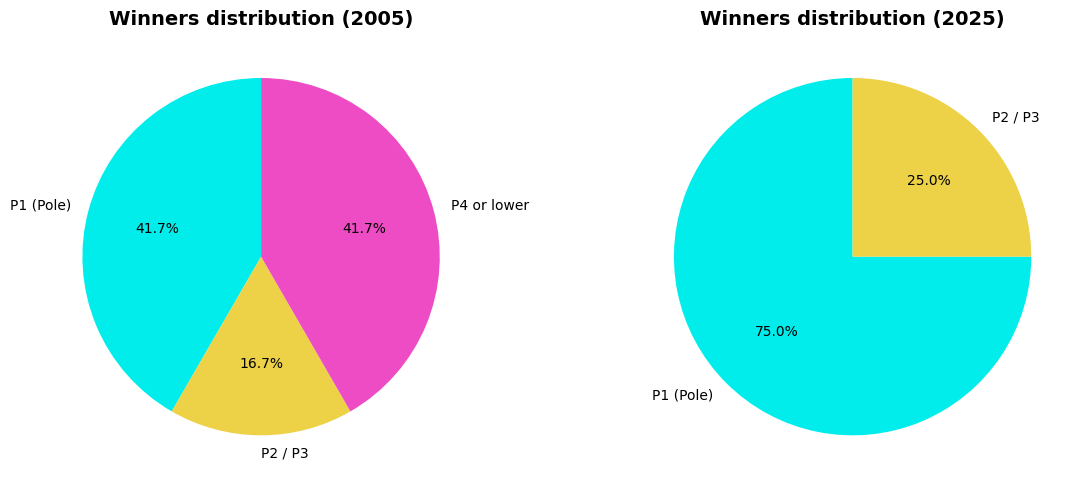

In [119]:
# Set up categories and color palette
labels = ['P1 (Pole)', 'P2 / P3', 'P4 or lower']
sizes_2005 = [mean_pole_2005, mean_no_pole_2005, p4_2005]
sizes_2025 = [mean_pole_2025, mean_no_pole_2025, p4_2025]
colors_graph = ['#00EDEB', '#EDD247', '#ED4CC4'] 

# Customization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Filtramos las etiquetas según el valor de cada año
labels_2005 = [label if size > 0 else '' for label, size in zip(labels, sizes_2005)]
labels_2025 = [label if size > 0 else '' for label, size in zip(labels, sizes_2025)]
formato_pct = lambda pct: f'{pct:.1f}%' if pct > 0 else ''

# Pie Chart 2005
axes[0].pie(sizes_2005, labels=labels_2005, autopct=formato_pct, startangle=90, colors=colors_graph)
axes[0].set_title('Winners distribution (2005)', fontsize=14, fontweight='bold')

# Pie Chart 2025
axes[1].pie(sizes_2025, labels=labels_2025, autopct=formato_pct, startangle=90, colors=colors_graph)
axes[1].set_title('Winners distribution (2025)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### Direct Tier Comparison (Bar Charts)

This section creates a three-panel bar chart comparing win percentages between 2005 and 2025 for each grid starting tier (P1, P2–P3, and P4+). 

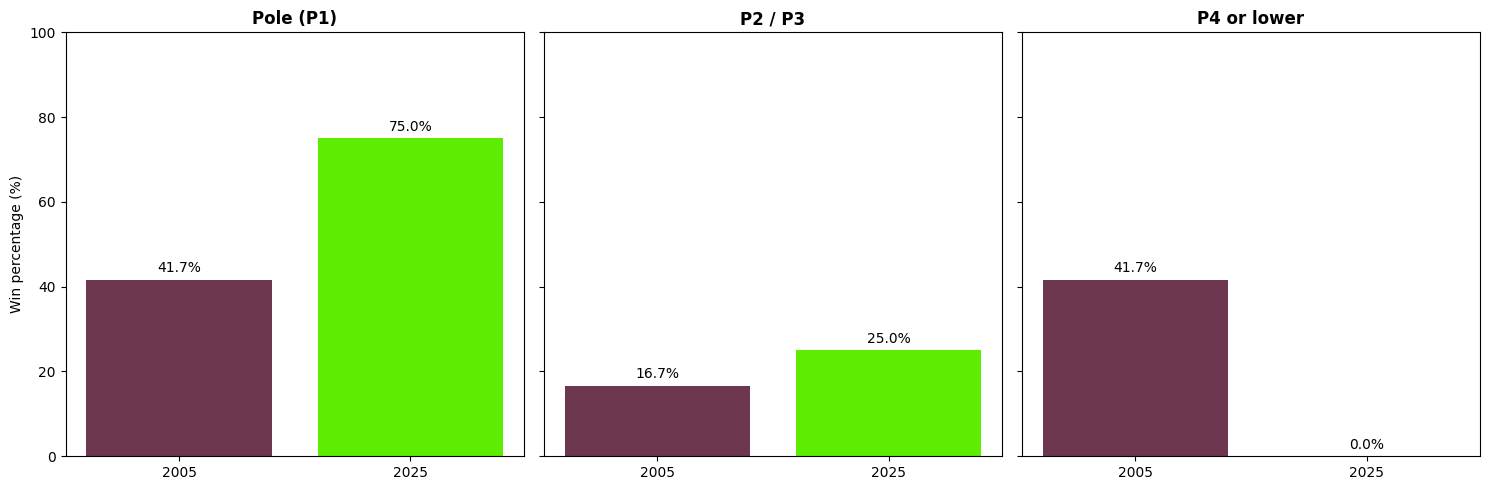

In [120]:
# Data for chart axes
anios = ['2005', '2025']
colores = ['#6E3750', '#5EED00']  

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# --- Subplot 1: Wins from Pole (P1) ---
bars1 = axes[0].bar(anios, [mean_pole_2005, mean_pole_2025], color=colores)
axes[0].set_title('Pole (P1)', fontweight='bold')
axes[0].set_ylabel('Win percentage (%)')
axes[0].bar_label(bars1, fmt='%.1f%%', padding=3)

# --- Subplot 2: Wins from P2 / P3 ---
bars2 = axes[1].bar(anios, [mean_no_pole_2005, mean_no_pole_2025], color=colores)
axes[1].set_title('P2 / P3', fontweight='bold')
axes[1].bar_label(bars2, fmt='%.1f%%', padding=3)

# --- Subplot 3: Wins from P4 or lower ---
bars3 = axes[2].bar(anios, [p4_2005, p4_2025], color=colores)
axes[2].set_title('P4 or lower', fontweight='bold')
axes[2].bar_label(bars3, fmt='%.1f%%', padding=3)

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### Key Insights & Conclusion

Even though 2025 rules make overtaking on track easier, the pole position driver is actually more likely to win the race in 2025 than in 2005. Here is why:

* **2005 (Fuel Strategy & Engine Failures):** In 2005, drivers qualified with the fuel they used for the race. Some drivers qualified with very little fuel to get Pole Position, but had to pit early. Drivers in 2nd or 3rd with more fuel could stay out longer and take the lead. On top of that, engine breakdowns were very common back then.
* **2025 (Pure Speed & Great Reliability):** In 2025, qualifying uses low fuel, showing who is truly the fastest driver on one lap. Modern cars almost never break down, and pit stops are super fast. Because of this, the driver on Pole usually keeps the lead until the finish line.

**Conclusion:** 2005 races were decided mostly by fuel strategy and car reliability. 2025 races are decided by pure speed and perfect team execution.